In [ ]:
import glob
import json
import logging
import sys
from os.path import dirname

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold

console_handler = logging.StreamHandler(sys.stdout)
file_handler = logging.FileHandler("logs/anysleep_dodo_vs_dodh_sfs.log", encoding="utf-8", mode="w")
formatter = logging.Formatter(
    "%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    "%Y-%m-%d %H:%M:%S",
)
console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)
logging.basicConfig(
    level=logging.INFO,
    handlers=[console_handler, file_handler],
)
logger = logging.getLogger(__name__)


def calc_mode(data, axis=0):
    bins = np.apply_along_axis(
        lambda x: np.bincount(x, minlength=5), axis=axis, arr=data
    )
    # resolve ties randomly by adding a small random number to the counts
    rand_mat = np.random.random_sample(bins.shape)
    bins = bins + rand_mat
    return np.argmax(bins, axis=axis)


dodoh_path = "../../logs/exp002/exp002a/sweep-2025-09-19_11-42-51_dod/"

dodoh_labels_glob = f"{dodoh_path}/*/labels.npz"
dodoh_preds_glob = f"{dodoh_path}/*/predictions.npz"
dodoh_labels_files = sorted(glob.glob(dodoh_labels_glob), key=lambda x: int(x.split("/")[-2]))
dodoh_preds_files = sorted(glob.glob(dodoh_preds_glob), key=lambda x: int(x.split("/")[-2]))

files_per_run_per_sr = {}
for label_file, pred_file in zip(dodoh_labels_files, dodoh_preds_files):
    with open(dirname(label_file) + "/predict-high-freq.log") as f:
        lines = f.readlines()
        sr_line = [line for line in lines if "sleep_stage_frequency" in line][0]
        sleep_stage_sr = int(sr_line.split("=")[1])
        model_run = [line for line in lines if "model.path=" in line][0]
        model_run = model_run.split("=")[1].strip()
    if model_run not in files_per_run_per_sr:
        files_per_run_per_sr[model_run] = {}
    files_per_run_per_sr[model_run][sleep_stage_sr] = (label_file, pred_file)

epoch_sr = 128 * 30
n_classes = 5
feature_block_duration = int(1.5 * 60 * 2)  # in epochs
possible_triplets = [f"{i}{j}{k}" for i in range(n_classes) for j in range(n_classes) for k in range(n_classes)
                     if i != j and j != k]


def calc_features(sleep_sr, pred_file, preds_per_epoch):
    features = {}
    preds_dict = np.load(pred_file)

    for dataset in ["dodo", "dodh"]:
        features[dataset] = {}
        rec_ids = [f.split("_")[1] for f in preds_dict.keys() if f.split("_")[0] == dataset]

        for rec in rec_ids:
            preds = preds_dict[f"{dataset}_{rec}"]

            sleep_start = np.where(preds_per_epoch[dataset][rec] != 0)[0][0]
            sleep_end = np.where(preds_per_epoch[dataset][rec] != 0)[0][-1]

            features[dataset][rec] = []
            for i in range(sleep_start, sleep_end, feature_block_duration):
                features[dataset][rec].append([0] * len(possible_triplets))
                features_block = preds[i * sleep_sr:min(i + feature_block_duration, sleep_end) * sleep_sr]
                features_block_1r = np.r_[features_block[0], features_block[:-1]]
                features_block_1l = np.r_[features_block[1:], features_block[-1]]

                # find triplets with a different element in the middle
                triplet_mask = \
                    np.where(((features_block - features_block_1r) != 0) & ((features_block - features_block_1l) != 0))[
                        0]

                for trip_idx in triplet_mask:
                    trip_str = f"{features_block[trip_idx - 1]}{features_block[trip_idx]}{features_block[trip_idx + 1]}"
                    features[dataset][rec][-1][possible_triplets.index(trip_str)] += 1

    return features

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier


def train_and_predict(features, train_recs, test_recs, n_exps):
    x_train = []
    y_train = []
    x_test = []
    y_test = []
    subject_mapping_train = []
    subject_mapping_test = []

    for dataset_name, subjects in features.items():
        for subject_name, subj_features in subjects.items():
            if subject_name in train_recs:
                x_train.extend(subj_features)
                y_train.extend([0 if dataset_name == "dodo" else 1] * len(subj_features))
                subject_mapping_train.extend([subject_name] * len(subj_features))
            elif subject_name in test_recs:
                x_test.extend(subj_features)
                y_test.extend([0 if dataset_name == "dodo" else 1] * len(subj_features))
                subject_mapping_test.extend([subject_name] * len(subj_features))
            else:
                raise ValueError(f"Subject {subject_name} not in train or test set")

    x_train = np.array(x_train)
    y_train = np.array(y_train)
    x_test = np.array(x_test)
    y_test = np.array(y_test)
    subject_mapping_train = np.array(subject_mapping_train)
    subject_mapping_test = np.array(subject_mapping_test)

    label_osa = []
    predict_osa = []
    selected_features = []
    sfs_scores = []
    for run_num in range(n_exps):
        y_pred, sel_feat, cv_scores = fit_and_predict(run_num, x_train, y_train, x_test, subject_mapping_train)

        y_test_subj = []
        y_pred_subj = []
        for subj in np.unique(subject_mapping_test):
            assert np.all(y_test[subject_mapping_test == subj] == y_test[subject_mapping_test == subj][0])
            y_test_subj.append(y_test[subject_mapping_test == subj][0])
            y_pred_subj.append(np.mean(y_pred[subject_mapping_test == subj]))

        label_osa.append(y_test_subj)
        predict_osa.append(y_pred_subj)
        selected_features.append(sel_feat)
        sfs_scores.append(cv_scores)

    return label_osa, predict_osa, selected_features, sfs_scores


with open("rnd_parameter_map_rndfcls.json", "r") as f:
    rnd_parameter_map = json.load(f)


def fit_and_predict(run_num, x_train, y_train, x_test, subject_mapping_train):
    clf = RandomForestClassifier(n_estimators=200, criterion="gini", class_weight="balanced",
                                 max_depth=rnd_parameter_map[run_num]["max_tree_depth"],
                                 min_samples_leaf=rnd_parameter_map[run_num]["min_samples_leaf"],
                                 min_samples_split=rnd_parameter_map[run_num]["min_samples_split"],
                                 max_features=rnd_parameter_map[run_num]["max_features"])

    n_features_to_select = 5
    selected_features_idcs = []
    scores = []
    for i in range(n_features_to_select):
        remain_feat = np.array(list(set(range(x_train.shape[1])) - set(selected_features_idcs)))

        with ProcessPoolExecutor(max_workers=32) as executor:
            partial_f = partial(sfs, x_train, y_train, clf, selected_features_idcs, subject_mapping_train)
            results = np.array(list(executor.map(partial_f, remain_feat)))
            best_score = max(results)
            best_feat = remain_feat[results == best_score]
            np.random.shuffle(best_feat)  # to avoid bias in selection
            best_feat = int(best_feat[0])  # take first if multiple features have same score
            logger.info(f"Previous features: {selected_features_idcs}, remaining features {remain_feat.tolist()}, "
                        f"scores {[f'{r:.4f}' for r in results]}, selected feature {best_feat}")

        selected_features_idcs = selected_features_idcs + [best_feat]
        scores.append(best_score)

    x_train_best_feat = x_train[:, selected_features_idcs]
    x_test_best_feat = x_test[:, selected_features_idcs]
    clf.fit(x_train_best_feat, y_train)
    y_pred = clf.predict(x_test_best_feat)

    return y_pred, selected_features_idcs, scores


def sfs(x_train, y_train, clf, previous_features, subject_mapping_train, current_feature):
    x_train_temp = x_train[:, previous_features + [current_feature]]

    subjects = np.unique(subject_mapping_train)
    subj_labels = np.array([y_train[subject_mapping_train == subj][0] for subj in subjects])
    skf = StratifiedKFold(n_splits=5, shuffle=True)
    folds = skf.split(subjects, subj_labels)
    scores = []
    for tr_subj, te_subj in folds:
        tr_subj_mask = np.isin(subject_mapping_train, subjects[tr_subj])
        te_subj_mask = np.isin(subject_mapping_train, subjects[te_subj])
        clf.fit(x_train_temp[tr_subj_mask], y_train[tr_subj_mask])
        y_pred = clf.predict(x_train_temp[te_subj_mask])

        y_pred_subj = []
        for subj in subjects[te_subj]:
            y_pred_subj.append(np.mean(y_pred[subject_mapping_train[te_subj_mask] == subj]))
        y_pred_subj = np.array(y_pred_subj)
        y_pred_subj_bin = (np.array(y_pred_subj) > 0.5).astype(int)
        y_pred_subj_bin[y_pred_subj == 0.5] = np.random.randint(0, 2, size=np.sum(y_pred_subj == 0.5))

        y_true_subj = subj_labels[te_subj]
        scores.append(f1_score(y_true_subj, y_pred_subj_bin, average="macro", zero_division=1))
    return np.mean(scores)

In [3]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

n_exps = 50
srs = [1, 256]

# data split
first_model_run = list(files_per_run_per_sr.keys())[0]
all_rec_ids = [k.split("_")[1] for k in np.load(files_per_run_per_sr[first_model_run][1][1]).keys()]
all_cohs = [1 if k.split("_")[0] == "dodh" else 0 for k in np.load(files_per_run_per_sr[first_model_run][1][1]).keys()]
train_recs, test_recs = train_test_split(all_rec_ids, test_size=0.2, random_state=42, stratify=all_cohs, shuffle=True)
logger.info(train_recs)
logger.info(test_recs)

mf1_scores = {}
sfs_features = {}
sfs_scores = {}
for model_run, files_per_sr in files_per_run_per_sr.items():
    logger.info(f"Model epoch: {model_run}")
    preds_dict = np.load(files_per_sr[1][1])
    preds_per_epoch = {"dodh": {k.split("_")[1]: v for k, v in preds_dict.items() if "dodh" in k},
                       "dodo": {k.split("_")[1]: v for k, v in preds_dict.items() if "dodo" in k}}
    mf1_scores[model_run] = {}
    sfs_features[model_run] = {}
    sfs_scores[model_run] = {}
    for sleep_stage_sr in srs:
        files = files_per_sr[sleep_stage_sr]
        features = calc_features(sleep_stage_sr, files[1], preds_per_epoch)
        label_osa, predict_osa, sel_feat, feat_scores = train_and_predict(features, train_recs, test_recs, n_exps)

        predict_osa = np.array(predict_osa)
        label_osa = np.array(label_osa)
        sel_feat = np.array(sel_feat)
        feat_scores = np.array(feat_scores)  # shape: (n_exps, n_features)

        predict_osa_bin = (predict_osa > 0.5).astype(int)
        predict_osa_bin[predict_osa == 0.5] = np.random.randint(0, 2, size=np.sum(predict_osa == 0.5))

        f1_array = []
        for i_exp in range(n_exps):
            cm = confusion_matrix(label_osa[i_exp], predict_osa_bin[i_exp])
            print(cm)
            precs, recs, f1s, _ = precision_recall_fscore_support(label_osa[i_exp], predict_osa_bin[i_exp],
                                                                  average=None, zero_division=1)
            f1_array.append(np.mean(f1s))

        logger.info(f"{sleep_stage_sr} sleep stages per epoch")
        logger.info(f"Avg. Makro F1: {np.mean(f1_array)}")
        logger.info(f"Std. Makro F1: {np.std(f1_array)}")
        logger.info("")
        mf1_scores[model_run][sleep_stage_sr] = f1_array
        sfs_features[model_run][sleep_stage_sr] = sel_feat
        sfs_scores[model_run][sleep_stage_sr] = feat_scores

2026-03-20 18:31:04 [INFO] __main__: ['730aba3b-e310-5be0-9eed-7c3123466834', '03341d0d-5927-5838-8a5f-1b8ef39d8f57', 'eb95076c-c470-56a4-b788-ace310f061c6', 'e8ec8ec4-dc48-50ce-985a-a06d87861030', '4b72b905-5521-5c57-b666-e20ff9bb195f', '7d778801-88e7-5086-ad1d-70f31a371876', 'a30245e3-4a71-565f-9636-92e7d2e825fc', 'c8110476-594c-533d-95bd-86147fccc987', 'c985916d-46a5-5c3e-9d50-a5a91f460bac', '02fb158a-a658-51ee-89cf-1e1dc2ebfde1', 'aadc9e0c-b7c3-5a47-851d-f21971d10935', '6e2aa933-c51c-5a31-8c7b-83da8d076a12', 'f2a69bdc-ed51-5e3f-b102-6b3f7d392be0', '0d79f4b1-e74f-5e87-8e42-f9dd7112ada5', 'a0c91989-530f-5117-80c1-2488dbed683c', '25a6b2b0-4d09-561b-82c6-f09bb271d3be', '7ab8ff5f-a77f-567d-9882-f8bee0c3c9bf', '22bea84c-5d23-5e49-bc2d-9764f883955b', 'b3706da5-748b-5dd1-a552-f57e4456cdf6', '18482adf-1144-54ca-9e35-27f65c43a105', 'a79d1f0e-c133-5aa0-8268-cdcc05825f0f', 'd5181c33-a43b-5dfe-8ad7-0337facb092a', 'aa160c78-6da3-5e05-8fc9-d6c13e9f97e0', '7f5237b1-2196-5c8a-9543-a5aa70210ef4', 'd

2026-03-20 18:31:04 [INFO] __main__: ['1da3544e-dc5c-5795-adc3-f5068959211f', '769df255-2284-50b3-8917-2155c759fbbd', 'ad47bc12-199c-5294-9cb8-4351bbbf7b5e', '4e3c4ac4-69e2-5347-a3b0-662c204d259d', 'c31a47f9-e400-5841-a22b-521c81042603', 'a25b2296-343b-53f6-8792-ada2669d466e', '742f1592-627c-54eb-bbb5-ccd55ffae33a', '52fbe46b-206c-584a-9f4f-1eb308e07bac', 'bb474ab0-c2ce-573b-8acd-ef86b0fa26a2', 'e59c45e0-0c0c-565f-84a9-6cf0ec5ef6c1', '1fa6c401-d819-50f5-8146-a0bb9e2b2516', '16450f5a-9b65-5536-85e1-93816c8b89eb', 'b3534fa3-7676-50dc-8412-07f0eff4f7a9', 'fc10ee0b-b863-511b-bce8-4dfa7af8ac3a', 'e72505f1-21be-5d66-b620-cfcfa2d754bc', 'a35a118e-e65e-5928-92a9-4354a6a0f4ce']


2026-03-20 18:31:04 [INFO] __main__: Model epoch: train-usleep-2025-07-21_12-03-51-final.pth


2026-03-20 18:31:07 [INFO] __main__: Previous features: [], remaining features [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79], scores ['0.4150', '0.4735', '0.3078', '0.2382', '0.2382', '0.2612', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.4909', '0.2612', '0.3078', '0.3078', '0.3338', '0.4827', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.3078', '0.2730', '0.3078', '0.5505', '0.3426', '0.3378', '0.3378', '0.4459', '0.5975', '0.3378', '0.3378', '0.3378', '0.3378', '0.4154', '0.3378', '0.3378', '0.3378', '0.4073', '0.3378', '0.3725', '0.4821', '0.3378', '0.3378', '0.3378', '0.3378', '0.3378', '0.3378', '0.4073', '0.3378', '0.4104', '0.3378', '

2026-03-20 18:31:10 [INFO] __main__: Previous features: [37], remaining features [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79], scores ['0.5650', '0.5461', '0.6110', '0.6110', '0.6246', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.5703', '0.6370', '0.6110', '0.6110', '0.5855', '0.5605', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6110', '0.6225', '0.6551', '0.6190', '0.6190', '0.6190', '0.6190', '0.6190', '0.6079', '0.6190', '0.5742', '0.6190', '0.6190', '0.6190', '0.6054', '0.6190', '0.6975', '0.6470', '0.6190', '0.6190', '0.6190', '0.6190', '0.6190', '0.6190', '0.6124', '0.6190', '0.5395', '0.6190', '0.6190', '0.

...

2026-03-20 20:08:39 [INFO] __main__: Previous features: [46, 75, 64, 65], remaining features [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 66, 67, 68, 69, 70, 71, 72, 73, 74, 76, 77, 78, 79], scores ['0.9193', '0.8611', '0.9071', '0.8465', '0.8311', '0.8069', '0.8409', '0.8378', '0.8600', '0.8905', '0.8735', '0.8281', '0.8399', '0.8472', '0.8710', '0.8662', '0.8400', '0.8482', '0.8901', '0.8935', '0.8931', '0.8426', '0.8766', '0.8903', '0.8905', '0.8465', '0.8858', '0.8761', '0.8171', '0.8518', '0.8353', '0.9028', '0.8760', '0.9016', '0.9480', '0.9118', '0.8240', '0.8196', '0.8947', '0.9242', '0.8827', '0.9242', '0.8480', '0.9132', '0.8743', '0.9094', '0.8956', '0.9093', '0.8931', '0.8955', '0.8527', '0.8771', '0.8580', '0.9490', '0.9227', '0.8562', '0.8244', '0.8992', '0.8606', '0.8881', '0.

[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[10  1]
 [ 0  5]]
[[9 2]
 [1 4]]
[[11  0]
 [ 0  5]]
[[10  1]
 [ 0  5]]
[[8 3]
 [0 5]]
[[8 3]
 [0 5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 1  4]]
[[11  0]
 [ 1  4]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[7 4]
 [0 5]]
[[11  0]
 [ 1  4]]
[[11  0]
 [ 0  5]]
[[10  1]
 [ 0  5]]
[[11  0]
 [ 1  4]]
[[11  0]
 [ 1  4]]
[[11  0]
 [ 0  5]]
[[8 3]
 [1 4]]
[[11  0]
 [ 1  4]]
[[11  0]
 [ 0  5]]
[[9 2]
 [0 5]]
[[10  1]
 [ 2  3]]
[[9 2]
 [0 5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[10  1]
 [ 1  4]]
[[10  1]
 [ 1  4]]
[[10  1]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[10  1]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[7 4]
 [1 4]]
[[10  1]
 [ 1  4]]
[[10  1]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[9 2]
 [0 5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[10  1]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 0  5]]
[[11  0]
 [ 1  4]]
[[11  0]
 [ 1  4]]
2026-03-20 20:08:40 [INFO] __main__: 256 sleep stages per epoch


2026-03-20 20:08:40 [INFO] __main__: Avg. Makro F1: 0.9277513719435916


2026-03-20 20:08:40 [INFO] __main__: Std. Makro F1: 0.08368760005199788


2026-03-20 20:08:40 [INFO] __main__: 


In [4]:
logger.info(mf1_scores)
logger.info(sfs_features)
logger.info(sfs_scores)

2026-03-20 20:08:40 [INFO] __main__: {'train-usleep-2025-07-21_12-03-51-final.pth': {1: [np.float64(0.6135265700483092), np.float64(0.6536796536796536), np.float64(0.6666666666666667), np.float64(0.5151515151515151), np.float64(0.6135265700483092), np.float64(0.5465587044534412), np.float64(0.45893719806763283), np.float64(0.6135265700483092), np.float64(0.6666666666666667), np.float64(0.45893719806763283), np.float64(0.5465587044534412), np.float64(0.36), np.float64(0.5465587044534412), np.float64(0.7333333333333334), np.float64(0.5151515151515151), np.float64(0.5465587044534412), np.float64(0.5636363636363637), np.float64(0.6536796536796536), np.float64(0.6536796536796536), np.float64(0.6), np.float64(0.6135265700483092), np.float64(0.38461538461538464), np.float64(0.5636363636363637), np.float64(0.5), np.float64(0.5), np.float64(0.4666666666666667), np.float64(0.6135265700483092), np.float64(0.5), np.float64(0.6), np.float64(0.6), np.float64(0.6), np.float64(0.6), np.float64(0.6), n

2026-03-20 20:08:40 [INFO] __main__: {'train-usleep-2025-07-21_12-03-51-final.pth': {1: array([[37, 48, 17, 25, 49],
       [37, 32, 55, 33,  5],
       [37, 48, 16, 14,  0],
       [ 1, 17, 75, 39, 70],
       [37, 48, 17,  9,  1],
       [37, 32, 56, 69, 70],
       [37, 71, 66, 48, 69],
       [37, 49, 23, 13, 48],
       [16, 48, 37, 62, 52],
       [37, 71, 73, 69, 48],
       [37, 32, 60, 48, 34],
       [32, 21,  6, 37, 17],
       [37, 32, 54, 17, 19],
       [ 1,  4, 20,  8, 68],
       [16, 30, 26, 32, 37],
       [37, 32, 57, 63, 22],
       [37, 48, 69, 52, 17],
       [37, 33, 40, 45, 32],
       [37, 32, 41, 60, 33],
       [37, 32, 35, 17, 38],
       [37, 48, 69, 66, 75],
       [37, 48, 21,  7,  5],
       [16, 69, 66, 73, 77],
       [37, 48, 17, 12, 45],
       [37, 48, 76, 67, 70],
       [ 1,  5, 19, 75, 49],
       [37,  1, 48, 49, 40],
       [37, 48, 17, 66, 55],
       [32, 37, 13, 19, 17],
       [37, 32, 36, 64, 76],
       [37, 32,  6, 24, 12],
       [32, 3

2026-03-20 20:08:40 [INFO] __main__: {'train-usleep-2025-07-21_12-03-51-final.pth': {1: array([[0.59746032, 0.69745933, 0.7347619 , 0.7347619 , 0.74062976],
       [0.5688137 , 0.71491597, 0.75679272, 0.71607561, 0.74350668],
       [0.61140056, 0.705401  , 0.73727358, 0.74965453, 0.70706767],
       [0.55564041, 0.58940943, 0.65740981, 0.69407096, 0.7108568 ],
       [0.63746572, 0.65913534, 0.74542951, 0.74542951, 0.74237407],
       [0.59627098, 0.64504386, 0.73421802, 0.72760037, 0.71834095],
       [0.53957621, 0.64965453, 0.64965453, 0.65987886, 0.6987535 ],
       [0.54733197, 0.68342105, 0.71      , 0.71      , 0.68916384],
       [0.53110209, 0.58040214, 0.71174087, 0.68829118, 0.72246449],
       [0.60084918, 0.68378151, 0.68378151, 0.70383287, 0.68373434],
       [0.58412698, 0.71301538, 0.71301538, 0.70749658, 0.68001823],
       [0.62944444, 0.63786181, 0.66588186, 0.6475    , 0.67226326],
       [0.62923255, 0.70280112, 0.70280112, 0.73957175, 0.73957175],
       [0.64233

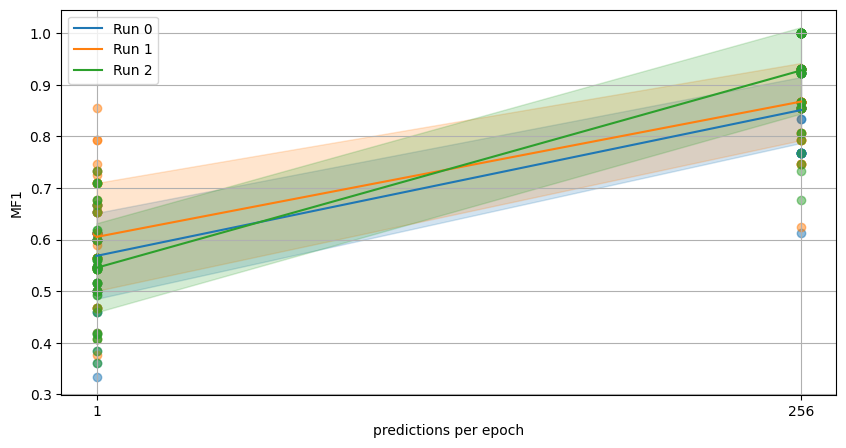

In [5]:
plt.figure(figsize=(10, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
for i, (model_run, mf1_scores_epoch) in enumerate(mf1_scores.items()):
    c = colors[i % len(colors)]
    means_to_plot = np.array(list(mf1_scores_epoch.values())).mean(axis=1)
    stds_to_plot = np.array(list(mf1_scores_epoch.values())).std(axis=1)
    plt.plot(range(len(mf1_scores_epoch)), means_to_plot, label=f"Run {i}", color=c)
    plt.fill_between(range(len(mf1_scores_epoch)), means_to_plot - stds_to_plot, means_to_plot + stds_to_plot,
                     alpha=0.2, color=c)
    plt.scatter(np.repeat(range(len(mf1_scores_epoch)), n_exps), np.array(list(mf1_scores_epoch.values())).flatten(),
                alpha=0.5, color=c)
first_key = next(iter(mf1_scores))
plt.xticks(range(len(mf1_scores[first_key])), list(mf1_scores[first_key].keys()))
plt.grid()
plt.xlabel("predictions per epoch")
plt.ylabel("MF1")
plt.legend()
plt.show()

In [1]:
import numpy as np

mf1_scores = {'train-usleep-2025-07-21_12-03-51-final.pth': {1: [0.6135265700483092, 0.6536796536796536, 0.6666666666666667, 0.5151515151515151, 0.6135265700483092, 0.5465587044534412, 0.45893719806763283, 0.6135265700483092, 0.6666666666666667, 0.45893719806763283, 0.5465587044534412, 0.36, 0.5465587044534412, 0.7333333333333334, 0.5151515151515151, 0.5465587044534412, 0.5636363636363637, 0.6536796536796536, 0.6536796536796536, 0.6, 0.6135265700483092, 0.38461538461538464, 0.5636363636363637, 0.5, 0.5, 0.4666666666666667, 0.6135265700483092, 0.5, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6666666666666667, 0.3333333333333333, 0.6135265700483092, 0.6, 0.6135265700483092, 0.5, 0.5, 0.6666666666666667, 0.5465587044534412, 0.6, 0.6, 0.6135265700483092, 0.6536796536796536, 0.6135265700483092, 0.6, 0.6135265700483092, 0.4181818181818182], 256: [0.7681159420289855, 0.8545454545454545, 0.7681159420289855, 0.9227053140096618, 0.9307359307359306, 0.8545454545454545, 0.8545454545454545, 0.8333333333333333, 0.7681159420289855, 0.8545454545454545, 0.8545454545454545, 0.9307359307359306, 0.8545454545454545, 0.8666666666666667, 0.8545454545454545, 0.9307359307359306, 0.7681159420289855, 0.8545454545454545, 0.9307359307359306, 0.8545454545454545, 0.9307359307359306, 0.8545454545454545, 0.9307359307359306, 0.9227053140096618, 0.8545454545454545, 0.8545454545454545, 0.9227053140096618, 0.8545454545454545, 0.7681159420289855, 0.8545454545454545, 0.8333333333333333, 0.9227053140096618, 0.8545454545454545, 0.9307359307359306, 0.6135265700483092, 0.8545454545454545, 0.7681159420289855, 0.9307359307359306, 0.7681159420289855, 0.9307359307359306, 0.8545454545454545, 0.7681159420289855, 0.7681159420289855, 0.8545454545454545, 0.8545454545454545, 0.8545454545454545, 0.8545454545454545, 0.8545454545454545, 0.8545454545454545, 0.7681159420289855]}, 'train-usleep-2025-07-21_12-04-20-final.pth': {1: [0.7090909090909091, 0.5151515151515151, 0.7922077922077921, 0.746031746031746, 0.5636363636363637, 0.7257142857142858, 0.5465587044534412, 0.5636363636363637, 0.7922077922077921, 0.6536796536796536, 0.6536796536796536, 0.5636363636363637, 0.6536796536796536, 0.4666666666666667, 0.5636363636363637, 0.7090909090909091, 0.4181818181818182, 0.7090909090909091, 0.6135265700483092, 0.4666666666666667, 0.6135265700483092, 0.8545454545454545, 0.6536796536796536, 0.5636363636363637, 0.7090909090909091, 0.6666666666666667, 0.4074074074074074, 0.5428571428571429, 0.6, 0.6666666666666667, 0.5, 0.7333333333333334, 0.4666666666666667, 0.4666666666666667, 0.5, 0.5897435897435898, 0.6666666666666667, 0.5428571428571429, 0.5428571428571429, 0.5636363636363637, 0.5465587044534412, 0.7333333333333334, 0.6761133603238867, 0.37662337662337664, 0.6135265700483092, 0.6, 0.5465587044534412, 0.6135265700483092, 0.5636363636363637, 0.7090909090909091], 256: [1.0, 0.746031746031746, 0.746031746031746, 0.8666666666666667, 0.9307359307359306, 0.8666666666666667, 0.9307359307359306, 0.9307359307359306, 0.8545454545454545, 0.8056680161943319, 0.8666666666666667, 0.9307359307359306, 0.7922077922077921, 0.8666666666666667, 0.8666666666666667, 0.8666666666666667, 0.9307359307359306, 0.8666666666666667, 0.9307359307359306, 0.9227053140096618, 0.8545454545454545, 0.8545454545454545, 0.746031746031746, 0.746031746031746, 0.8666666666666667, 0.8666666666666667, 0.9307359307359306, 0.7922077922077921, 0.8666666666666667, 1.0, 0.7922077922077921, 0.7922077922077921, 0.625, 0.9307359307359306, 0.9307359307359306, 1.0, 0.8545454545454545, 0.8666666666666667, 0.8666666666666667, 0.8666666666666667, 0.8666666666666667, 0.8666666666666667, 0.8545454545454545, 1.0, 0.8056680161943319, 0.8666666666666667, 0.8666666666666667, 1.0, 0.8666666666666667, 0.8056680161943319]}, 'train-usleep-2025-07-21_12-04-54-final.pth': {1: [0.5465587044534412, 0.5636363636363637, 0.5151515151515151, 0.5465587044534412, 0.7090909090909091, 0.5428571428571429, 0.5428571428571429, 0.5607843137254902, 0.41700404858299595, 0.6536796536796536, 0.5607843137254902, 0.6190476190476191, 0.5151515151515151, 0.5607843137254902, 0.5428571428571429, 0.4666666666666667, 0.5151515151515151, 0.5, 0.4920634920634921, 0.5428571428571429, 0.6, 0.5465587044534412, 0.6761133603238867, 0.5, 0.7090909090909091, 0.5428571428571429, 0.45893719806763283, 0.5428571428571429, 0.5465587044534412, 0.36, 0.5465587044534412, 0.5636363636363637, 0.6666666666666667, 0.5465587044534412, 0.6190476190476191, 0.5151515151515151, 0.41700404858299595, 0.38461538461538464, 0.5428571428571429, 0.5636363636363637, 0.4074074074074074, 0.5, 0.4181818181818182, 0.5607843137254902, 0.7333333333333334, 0.6761133603238867, 0.4074074074074074, 0.7090909090909091, 0.4920634920634921, 0.6], 256: [1.0, 1.0, 0.9307359307359306, 0.7922077922077921, 1.0, 0.9307359307359306, 0.8056680161943319, 0.8056680161943319, 1.0, 0.9227053140096618, 0.9227053140096618, 1.0, 1.0, 1.0, 1.0, 0.746031746031746, 0.9227053140096618, 1.0, 0.9307359307359306, 0.9227053140096618, 0.9227053140096618, 1.0, 0.7333333333333334, 0.9227053140096618, 1.0, 0.8666666666666667, 0.7681159420289855, 0.8666666666666667, 1.0, 1.0, 0.8545454545454545, 0.8545454545454545, 0.9307359307359306, 1.0, 1.0, 0.9307359307359306, 1.0, 0.6761133603238867, 0.8545454545454545, 0.9307359307359306, 1.0, 1.0, 0.8666666666666667, 1.0, 1.0, 0.9307359307359306, 1.0, 1.0, 0.9227053140096618, 0.9227053140096618]}}

mean_scores = {}
for k, v in mf1_scores.items():
    for sr, f1 in v.items():
        if sr not in mean_scores:
            mean_scores[sr] = []
        mean_scores[sr].extend(f1)
mean_scores = {k: np.mean(v) for k, v in mean_scores.items()}
mean_scores

{1: np.float64(0.5729526541978286), 256: np.float64(0.8820306411530668)}